In [26]:
import pandas as pandas
tran=pandas.read_csv("transactions_history_final.csv")
dis=pandas.read_csv("distributor_seasonality_details.csv")
holid=pandas.read_csv("holiday_list.csv")
out=pandas.read_csv("outlet_master.csv")
out1=pandas.read_csv("outlet_coordinates.csv")

tran.head()
tran.info()
tran.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2376389 entries, 0 to 2376388
Data columns (total 7 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Outlet_ID         object 
 1   Year              int64  
 2   Month             int64  
 3   Distributor_ID    object 
 4   SKU_ID            object 
 5   Volume_Liters     float64
 6   Total_Bill_Value  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 126.9+ MB


,Year,Month,Volume_Liters,Total_Bill_Value
count,2.376389e+06,2.376389e+06,2.376389e+06,2.376389e+06
mean,2.024000e+03,6.499014e+00,5.262422e+01,1.379062e+04
std,8.165350e-01,3.449912e+00,9.548678e+01,1.644881e+04
min,2.023000e+03,1.000000e+00,-9.564408e+02,-1.411536e+05
25%,2.023000e+03,3.000000e+00,1.018487e+01,3.527437e+03
50%,2.024000e+03,6.000000e+00,2.315845e+01,8.060190e+03
75%,2.025000e+03,9.000000e+00,5.443157e+01,1.629443e+04
max,2.025000e+03,1.200000e+01,9.438578e+03,1.528457e+05


In [27]:
dis.head()
dis.info()
dis.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Distributor_ID     360 non-null    object
 1   Year               360 non-null    int64 
 2   Month              360 non-null    int64 
 3   Seasonality_Index  360 non-null    object
dtypes: int64(2), object(2)
memory usage: 11.4+ KB


,Year,Month
count,360.000000,360.000000
mean,2024.000000,6.500000
std,0.817633,3.456857
min,2023.000000,1.000000
25%,2023.000000,3.750000
50%,2024.000000,6.500000
75%,2025.000000,9.250000
max,2025.000000,12.000000


In [28]:
holid.head()
holid.info()
holid.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          349 non-null    object
 1   Holiday_Name  349 non-null    object
 2   Holiday_Type  349 non-null    object
dtypes: object(3)
memory usage: 8.3+ KB


,Date,Holiday_Name,Holiday_Type
count,349,349,349
unique,76,41,4
top,2023-01-06T00:00:00Z,Navam Full Moon Poya Day,Bank
freq,8,18,99


In [29]:
out.head() 
out.info()
out.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Outlet_ID     20000 non-null  object
 1   Outlet_Size   19804 non-null  object
 2   Cooler_Count  20000 non-null  int64 
 3   Outlet_Type   20000 non-null  object
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


,Cooler_Count
count,20000.000000
mean,1.291000
std,1.375505
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


In [30]:
out1.head()
out1.info() 
out1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Outlet_ID  20000 non-null  object 
 1   Latitude   20000 non-null  float64
 2   Longitude  20000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 468.9+ KB


,Latitude,Longitude
count,20000.000000,20000.000000
mean,7.739852,79.285245
std,7.303732,8.103265
min,0.000000,0.000000
25%,6.811049,79.925880
50%,7.022154,80.058188
75%,7.350576,80.456441
max,80.792317,80.799952


In [31]:
merged=pandas.merge(out, out1, on="Outlet_ID")
mer=pandas.merge(merged, tran, on="Outlet_ID")
print(mer.head())

   Outlet_ID Outlet_Size  Cooler_Count Outlet_Type  Latitude  Longitude  Year  \
0  OUT_00001      Medium             1      Grocry  7.089846  79.979055  2024   
1  OUT_00001      Medium             1      Grocry  7.089846  79.979055  2024   
2  OUT_00001      Medium             1      Grocry  7.089846  79.979055  2024   
3  OUT_00001      Medium             1      Grocry  7.089846  79.979055  2025   
4  OUT_00001      Medium             1      Grocry  7.089846  79.979055  2023   

   Month Distributor_ID  SKU_ID  Volume_Liters  Total_Bill_Value  
0     10      DIST_W_03  SKU_10      22.176467       8188.261340  
1     10      DIST_W_03  SKU_03      22.033342       7711.623610  
2     11      DIST_W_03  SKU_05      55.877286       5028.984015  
3      6      DIST_W_03  SKU_09      10.175353      22385.794938  
4      6      DIST_W_03  SKU_05      42.555307       3829.944721  


In [32]:
mer.to_csv("final.csv", index=False)


In [33]:
fin=pandas.read_csv("final.csv")
fin.info()
fin.describe()
fin.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2376389 entries, 0 to 2376388
Data columns (total 12 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Outlet_ID         object 
 1   Outlet_Size       object 
 2   Cooler_Count      int64  
 3   Outlet_Type       object 
 4   Latitude          float64
 5   Longitude         float64
 6   Year              int64  
 7   Month             int64  
 8   Distributor_ID    object 
 9   SKU_ID            object 
 10  Volume_Liters     float64
 11  Total_Bill_Value  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 217.6+ MB


,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type,Latitude,Longitude,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value
0,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2024,10,DIST_W_03,SKU_10,22.176467,8188.261340
1,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2024,10,DIST_W_03,SKU_03,22.033342,7711.623610
2,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2024,11,DIST_W_03,SKU_05,55.877286,5028.984015
3,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2025,6,DIST_W_03,SKU_09,10.175353,22385.794938
4,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2023,6,DIST_W_03,SKU_05,42.555307,3829.944721


In [34]:
fin.isnull().sum()


Outlet_ID               0
Outlet_Size         11604
Cooler_Count            0
Outlet_Type             0
Latitude                0
Longitude               0
Year                    0
Month                   0
Distributor_ID          0
SKU_ID                  0
Volume_Liters           0
Total_Bill_Value        0
dtype: int64

In [35]:
dis.isnull().sum()


Distributor_ID       0
Year                 0
Month                0
Seasonality_Index    0
dtype: int64

In [36]:
holid.isnull().sum()

Date            0
Holiday_Name    0
Holiday_Type    0
dtype: int64

In [37]:
duplicates = fin[fin.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Outlet_ID, Outlet_Size, Cooler_Count, Outlet_Type, Latitude, Longitude, Year, Month, Distributor_ID, SKU_ID, Volume_Liters, Total_Bill_Value]
Index: []


In [38]:
duplicates = dis[dis.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Distributor_ID, Year, Month, Seasonality_Index]
Index: []


In [39]:
duplicates = holid[holid.duplicated()]
print(duplicates)

                     Date                Holiday_Name Holiday_Type
105  2024-03-24T00:00:00Z    Medin Full Moon Poya Day       Public
126  2024-02-23T00:00:00Z    Navam Full Moon Poya Day     Poya Day
127  2024-03-24T00:00:00Z    Medin Full Moon Poya Day     Poya Day
128  2024-04-24T00:00:00Z      Bak Full Moon Poya Day     Poya Day
129  2024-05-23T00:00:00Z    Vesak Full Moon Poya Day     Poya Day
..                    ...                         ...          ...
270  2023-11-26T00:00:00Z       Il Full Moon Poya Day   Mercantile
271  2023-12-25T00:00:00Z               Christmas Day   Mercantile
272  2023-12-26T00:00:00Z  Unduvap Full Moon Poya Day   Mercantile
295  2025-02-12T00:00:00Z    Navam Full Moon Poya Day     Poya Day
303  2025-08-10T00:00:00Z   Nikini Full Moon Poya Day     Poya Day

[93 rows x 3 columns]


In [40]:
duplicate_holidays = holid[
    holid.duplicated(
        subset=['Date', 'Holiday_Name'],
        keep=False
    )
]

print(duplicate_holidays)

                     Date                                       Holiday_Name  \
0    2023-01-06T00:00:00Z                         Duruthu Full Moon Poya Day   
1    2023-01-15T00:00:00Z                              Tamil Thai Pongal Day   
2    2023-01-16T00:00:00Z  Additional Holiday in lieu of Tamil Thai Ponga...   
3    2023-02-03T00:00:00Z  Additional Half Holiday in lieu of the Indepen...   
4    2023-02-04T00:00:00Z                                       National Day   
..                    ...                                                ...   
344  2025-09-07T00:00:00Z                          Binara Full Moon Poya Day   
345  2025-10-06T00:00:00Z                             Vap Full Moon Poya Day   
346  2025-11-05T00:00:00Z                             Ill Full Moon Poya Day   
347  2025-12-04T00:00:00Z                         Unduvap Full Moon Poya Day   
348  2025-12-25T00:00:00Z                                      Christmas Day   

    Holiday_Type  
0         Public  
1

In [41]:
holid['Date'] = pandas.to_datetime(
    holid['Date']
)
holid['Year'] = holid['Date'].dt.year
holid['Month'] = holid['Date'].dt.month

In [42]:
holiday_features = holid.groupby('Date').agg({
    'Holiday_Name': lambda x: ', '.join(x.unique()),
    'Holiday_Type': lambda x: ', '.join(x.unique())
})
holiday_features

,Holiday_Name,Holiday_Type
Date,,
2023-01-06 00:00:00+00:00,Duruthu Full Moon Poya Day,"Public, Poya Day, Bank, Mercantile"
2023-01-15 00:00:00+00:00,Tamil Thai Pongal Day,"Public, Bank, Mercantile"
2023-01-16 00:00:00+00:00,Additional Holiday in lieu of Tamil Thai Ponga...,"Public, Bank, Mercantile"
2023-02-03 00:00:00+00:00,Additional Half Holiday in lieu of the Indepen...,"Public, Bank, Mercantile"
2023-02-04 00:00:00+00:00,National Day,"Public, Bank, Mercantile"
...,...,...
2025-09-07 00:00:00+00:00,Binara Full Moon Poya Day,"Public, Bank, Mercantile"
2025-10-06 00:00:00+00:00,Vap Full Moon Poya Day,"Public, Poya Day, Bank, Mercantile"
2025-11-05 00:00:00+00:00,Ill Full Moon Poya Day,"Public, Poya Day, Bank, Mercantile"


In [56]:
#fin[fin['Volume_Liters'] < 0]
#fin[fin['Total_Bill_Value'] < 0]
fin = fin[
    (fin["Latitude"].between(5, 10)) & (fin["Longitude"].between(79, 82))
]
fin


,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type,Latitude,Longitude,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value
0,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2024,10,DIST_W_03,SKU_10,22.176467,8188.261340
1,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2024,10,DIST_W_03,SKU_03,22.033342,7711.623610
2,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2024,11,DIST_W_03,SKU_05,55.877286,5028.984015
3,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2025,6,DIST_W_03,SKU_09,10.175353,22385.794938
4,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2023,6,DIST_W_03,SKU_05,42.555307,3829.944721
...,...,...,...,...,...,...,...,...,...,...,...,...
2376384,OUT_20000,Small,0,Hotel,6.215872,80.342792,2025,1,DIST_S_02,SKU_01,5.101613,11223.544297
2376385,OUT_20000,Small,0,Hotel,6.215872,80.342792,2024,2,DIST_S_02,SKU_04,7.500609,2437.710558
2376386,OUT_20000,Small,0,Hotel,6.215872,80.342792,2025,11,DIST_S_02,SKU_01,6.636228,1990.902918
2376387,OUT_20000,Small,0,Hotel,6.215872,80.342792,2024,2,DIST_S_02,SKU_05,16.794239,1511.518815


In [65]:
fin.drop(
    fin[(fin["Volume_Liters"]<0) & (fin["Total_Bill_Value"]<0)].index,inplace=True
)
fin

,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type,Latitude,Longitude,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value
0,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2024,10,DIST_W_03,SKU_10,22.176467,8188.261340
1,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2024,10,DIST_W_03,SKU_03,22.033342,7711.623610
2,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2024,11,DIST_W_03,SKU_05,55.877286,5028.984015
3,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2025,6,DIST_W_03,SKU_09,10.175353,22385.794938
4,OUT_00001,Medium,1,Grocry,7.089846,79.979055,2023,6,DIST_W_03,SKU_05,42.555307,3829.944721
...,...,...,...,...,...,...,...,...,...,...,...,...
2376384,OUT_20000,Small,0,Hotel,6.215872,80.342792,2025,1,DIST_S_02,SKU_01,5.101613,11223.544297
2376385,OUT_20000,Small,0,Hotel,6.215872,80.342792,2024,2,DIST_S_02,SKU_04,7.500609,2437.710558
2376386,OUT_20000,Small,0,Hotel,6.215872,80.342792,2025,11,DIST_S_02,SKU_01,6.636228,1990.902918
2376387,OUT_20000,Small,0,Hotel,6.215872,80.342792,2024,2,DIST_S_02,SKU_05,16.794239,1511.518815


In [67]:
fin['Volume_Liters'].describe()

count    2.342728e+06
mean     5.281008e+01
std      9.536244e+01
min      0.000000e+00
25%      1.023142e+01
50%      2.320312e+01
75%      5.449699e+01
max      9.438578e+03
Name: Volume_Liters, dtype: float64

In [78]:
fin['Outlet_Type'] = (
    fin['Outlet_Type']
    .str.lower()
    .str.strip()
)

In [68]:
monthly_sales = fin.groupby(
    ['Distributor_ID', 'Year', 'Month']
)['Volume_Liters'].sum().reset_index()

In [69]:
avg_sales = monthly_sales.groupby(
    'Distributor_ID'
)['Volume_Liters'].mean().reset_index()

avg_sales.rename(
    columns={'Volume_Liters': 'avg_distributor_sales'},
    inplace=True
)

In [70]:
monthly_sales = monthly_sales.merge(
    avg_sales,
    on='Distributor_ID'
)

In [72]:
monthly_sales['Seasonality_Index'] = (
    monthly_sales['Volume_Liters'] /
    monthly_sales['avg_distributor_sales']
)
monthly_sales

,Distributor_ID,Year,Month,Volume_Liters,avg_distributor_sales,Seasonality_Index
0,DIST_C_01,2023,1,224594.737494,250017.067262,0.898318
1,DIST_C_01,2023,2,224113.877036,250017.067262,0.896394
2,DIST_C_01,2023,3,221209.897004,250017.067262,0.884779
3,DIST_C_01,2023,4,319282.181397,250017.067262,1.277042
4,DIST_C_01,2023,5,227646.262789,250017.067262,0.910523
...,...,...,...,...,...,...
355,DIST_W_03,2025,8,512725.923163,515068.572423,0.995452
356,DIST_W_03,2025,9,506389.036911,515068.572423,0.983149
357,DIST_W_03,2025,10,509172.844122,515068.572423,0.988554
358,DIST_W_03,2025,11,504492.761581,515068.572423,0.979467


In [75]:
valid_outlets = fin['Outlet_ID'].unique()

bad_outlets = fin[
    ~fin['Outlet_ID'].isin(valid_outlets)
]
bad_outlets

,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type,Latitude,Longitude,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value


In [77]:
fin[fin.duplicated()]

,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type,Latitude,Longitude,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value


In [73]:
fin['Distributor_ID'].value_counts()

Distributor_ID
DIST_W_02     360850
DIST_W_01     359581
DIST_W_03     357709
DIST_NW_01    236103
DIST_NW_02    233787
DIST_S_02     166311
DIST_S_01     165544
DIST_C_01     161746
DIST_C_03     151240
DIST_C_02     149857
Name: count, dtype: int64

In [80]:
result=fin.merge(monthly_sales, on=['Distributor_ID', 'Year', 'Month'], how='left')
result.to_csv("final_with_seasonality.csv", index=False)

In [81]:
holiday_features.to_csv("holiday_features.csv", index=True)

In [94]:
fi=pandas.read_csv("final_with_seasonality.csv")
ho=pandas.read_csv("holiday_features.csv")
fi = fi.sort_values(by=['Outlet_ID', 'Year', 'Month'])
fi

,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type,Latitude,Longitude,Year,Month,Distributor_ID,SKU_ID,Volume_Liters_x,Total_Bill_Value,Volume_Liters_y,avg_distributor_sales,Seasonality_Index
5,OUT_00001,Medium,1,grocry,7.089846,79.979055,2023,3,DIST_W_03,SKU_02,79.993079,20264.933577,520683.949733,515068.572423,1.010902
6,OUT_00001,Medium,1,grocry,7.089846,79.979055,2023,3,DIST_W_03,SKU_09,16.425555,36136.242964,520683.949733,515068.572423,1.010902
10,OUT_00001,Medium,1,grocry,7.089846,79.979055,2023,3,DIST_W_03,SKU_06,282.573656,23736.162691,520683.949733,515068.572423,1.010902
26,OUT_00001,Medium,1,grocry,7.089846,79.979055,2023,3,DIST_W_03,SKU_06,227.246029,19088.625328,520683.949733,515068.572423,1.010902
34,OUT_00001,Medium,1,grocry,7.089846,79.979055,2023,3,DIST_W_03,SKU_07,57.960045,37674.058157,520683.949733,515068.572423,1.010902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2342691,OUT_20000,Small,0,hotel,6.215872,80.342792,2025,10,DIST_S_02,SKU_02,13.889754,3518.783767,219917.143559,240101.923355,0.915932
2342708,OUT_20000,Small,0,hotel,6.215872,80.342792,2025,10,DIST_S_02,SKU_06,58.038714,4875.219239,219917.143559,240101.923355,0.915932
2342709,OUT_20000,Small,0,hotel,6.215872,80.342792,2025,10,DIST_S_02,SKU_09,2.854302,6279.426486,219917.143559,240101.923355,0.915932
2342701,OUT_20000,Small,0,hotel,6.215872,80.342792,2025,11,DIST_S_02,SKU_07,15.684193,10194.760233,215763.079119,240101.923355,0.898631


In [95]:
ho['Date'] = pandas.to_datetime(
    ho['Date']
)
ho['Year'] = ho['Date'].dt.year
ho['Month'] = ho['Date'].dt.month

In [105]:
holiday_features = ho.groupby(
    ['Year', 'Month']).agg(
    Holiday_Count=('Holiday_Name', 'count'),

    
).reset_index()

In [106]:
holiday_features

,Year,Month,Holiday_Count
0,2023,1,3
1,2023,2,3
2,2023,3,1
3,2023,4,4
4,2023,5,4
5,2023,6,1
6,2023,7,1
7,2023,8,2
8,2023,9,2
9,2023,10,1


In [107]:
fi = fi.merge(
    holiday_features,
    on=['Year', 'Month'],
    how='left'
)

In [114]:
fi = fi.sort_values(by=['Outlet_ID', 'Year', 'Month','SKU_ID'])


In [115]:
fi

,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type,Latitude,Longitude,Year,Month,Distributor_ID,SKU_ID,Volume_Liters_x,Total_Bill_Value,Volume_Liters_y,avg_distributor_sales,Seasonality_Index,Holiday_Count
5,OUT_00001,Medium,1,grocry,7.089846,79.979055,2023,3,DIST_W_03,SKU_01,34.570480,10371.113934,520683.949733,515068.572423,1.010902,1
23,OUT_00001,Medium,1,grocry,7.089846,79.979055,2023,3,DIST_W_03,SKU_01,31.527238,9458.178265,520683.949733,515068.572423,1.010902,1
0,OUT_00001,Medium,1,grocry,7.089846,79.979055,2023,3,DIST_W_03,SKU_02,79.993079,20264.933577,520683.949733,515068.572423,1.010902,1
17,OUT_00001,Medium,1,grocry,7.089846,79.979055,2023,3,DIST_W_03,SKU_02,104.803031,26550.052318,520683.949733,515068.572423,1.010902,1
13,OUT_00001,Medium,1,grocry,7.089846,79.979055,2023,3,DIST_W_03,SKU_03,25.600579,8960.196446,520683.949733,515068.572423,1.010902,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2342723,OUT_20000,Small,0,hotel,6.215872,80.342792,2025,10,DIST_S_02,SKU_02,13.889754,3518.783767,219917.143559,240101.923355,0.915932,1
2342724,OUT_20000,Small,0,hotel,6.215872,80.342792,2025,10,DIST_S_02,SKU_06,58.038714,4875.219239,219917.143559,240101.923355,0.915932,1
2342725,OUT_20000,Small,0,hotel,6.215872,80.342792,2025,10,DIST_S_02,SKU_09,2.854302,6279.426486,219917.143559,240101.923355,0.915932,1
2342727,OUT_20000,Small,0,hotel,6.215872,80.342792,2025,11,DIST_S_02,SKU_01,6.636228,1990.902918,215763.079119,240101.923355,0.898631,1


In [123]:
fi_agg = fi.groupby(
    ['Outlet_ID', 'Year', 'Month']
).agg({
    'Volume_Liters_x': 'sum',
    'Total_Bill_Value': 'sum',
    'SKU_ID': 'nunique',
    'Cooler_Count': 'max',
    'Outlet_Size': 'first',
    'Outlet_Type': 'first',
    'Holiday_Count': 'first',
    'Seasonality_Index': 'mean'
}).reset_index()

In [120]:
fi_agg.rename(columns={
    'Volume_Liters_x': 'Outlet_Volume',
    'SKU_ID': 'SKU_Count'
}, inplace=True)

In [124]:
fi_agg

,Outlet_ID,Year,Month,Volume_Liters_x,Total_Bill_Value,SKU_ID,Cooler_Count,Outlet_Size,Outlet_Type,Holiday_Count,Seasonality_Index
0,OUT_00001,2023,3,1390.918670,398271.118522,10,1,Medium,grocry,1,1.010902
1,OUT_00001,2023,6,382.687950,100870.517231,9,1,Medium,grocry,1,0.649452
2,OUT_00001,2023,8,552.713934,147318.575355,7,1,Medium,grocry,2,0.961969
3,OUT_00001,2023,10,541.861465,107725.488528,6,1,Medium,grocry,1,0.977543
4,OUT_00001,2023,11,242.525695,60446.688868,5,1,Medium,grocry,1,0.971106
...,...,...,...,...,...,...,...,...,...,...,...
445185,OUT_20000,2025,4,17.167358,14862.674065,3,0,Small,hotel,5,1.308548
445186,OUT_20000,2025,6,14.509274,3960.499584,2,0,Small,hotel,1,0.596658
445187,OUT_20000,2025,7,102.154122,19611.794166,3,0,Small,hotel,1,0.893911
445188,OUT_20000,2025,10,74.782771,14673.429492,3,0,Small,hotel,1,0.915932


In [125]:
outlet_max = fi_agg.groupby('Outlet_ID')['Volume_Liters_x'].max()
fii = fi_agg.merge(
    outlet_max.rename('Outlet_Max_Historical'),
    on='Outlet_ID',
    how='left'
)
fii['Potential'] = fii['Outlet_Max_Historical'] * 1.2

In [126]:
fii['Potential'] = fii.groupby('Outlet_ID')['Volume_Liters_x']\
                     .transform(lambda x: x.quantile(0.95) * 1.3)

In [127]:
featur = fii[[
    'Cooler_Count',
    'SKU_ID',
    'Holiday_Count',
    'Seasonality_Index',
    'Outlet_Size',
    'Outlet_Type'
]]

In [129]:
from sklearn.preprocessing import LabelEncoder

fii['Outlet_Type'] = LabelEncoder().fit_transform(fii['Outlet_Type'])
fii['Outlet_Size'] = LabelEncoder().fit_transform(fii['Outlet_Size'])

In [133]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(featur, fii['Potential'])

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [134]:
fii['Predicted_Potential'] = model.predict(featur)

In [ ]:
final = fii[['Outlet_ID','Year','Month','Predicted_Potential']]

In [160]:
finl = fii[['Outlet_ID','Predicted_Potential']]

In [161]:
finl.to_csv("Zybots.csv", index=False)

In [162]:
submission = finl.groupby(
    'Outlet_ID'
)['Predicted_Potential'].max().reset_index()

In [163]:
submission.rename(columns={
    'Predicted_Potential': 'Maximum_Monthly_Liters'
}, inplace=True)

In [164]:
submission.to_csv(
    'Zybots.csv',
    index=False
)

In [137]:
final

,Outlet_ID,Year,Month,Predicted_Potential
0,OUT_00001,2023,3,1827.578966
1,OUT_00001,2023,6,1540.578776
2,OUT_00001,2023,8,896.679586
3,OUT_00001,2023,10,661.789361
4,OUT_00001,2023,11,700.702570
...,...,...,...,...
445185,OUT_20000,2025,4,128.083158
445186,OUT_20000,2025,6,136.714548
445187,OUT_20000,2025,7,126.009066
445188,OUT_20000,2025,10,124.894228


In [ ]:
fii


,Outlet_ID,Year,Month,Volume_Liters_x,Total_Bill_Value,SKU_ID,Cooler_Count,Outlet_Size,Outlet_Type,Holiday_Count,Seasonality_Index,Outlet_Max_Historical,Potential,Predicted_Potential
0,OUT_00001,2023,3,1390.918670,398271.118522,10,1,2,4,1,1.010902,1941.470001,1822.015787,1827.578966
1,OUT_00001,2023,6,382.687950,100870.517231,9,1,2,4,1,0.649452,1941.470001,1822.015787,1540.578776
2,OUT_00001,2023,8,552.713934,147318.575355,7,1,2,4,2,0.961969,1941.470001,1822.015787,896.679586
3,OUT_00001,2023,10,541.861465,107725.488528,6,1,2,4,1,0.977543,1941.470001,1822.015787,661.789361
4,OUT_00001,2023,11,242.525695,60446.688868,5,1,2,4,1,0.971106,1941.470001,1822.015787,700.702570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445185,OUT_20000,2025,4,17.167358,14862.674065,3,0,3,5,5,1.308548,102.154122,106.113291,128.083158
445186,OUT_20000,2025,6,14.509274,3960.499584,2,0,3,5,1,0.596658,102.154122,106.113291,136.714548
445187,OUT_20000,2025,7,102.154122,19611.794166,3,0,3,5,1,0.893911,102.154122,106.113291,126.009066
445188,OUT_20000,2025,10,74.782771,14673.429492,3,0,3,5,1,0.915932,102.154122,106.113291,124.894228


In [155]:
fii.to_csv("final_predictions.csv", index=False)

In [148]:
features = [
    'Cooler_Count',
    'SKU_ID',
    'Holiday_Count',
    'Seasonality_Index',
    'Outlet_Size',
    'Outlet_Type'
]

In [150]:
from sklearn.model_selection import train_test_split

X = fii[features]
y = fii['Potential']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [151]:
from lightgbm import LGBMRegressor

model = LGBMRegressor()
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002477 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 288
[LightGBM] [Info] Number of data points in the train set: 356152, number of used features: 6
[LightGBM] [Info] Start training from score 580.490700


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [152]:
from sklearn.metrics import r2_score, mean_absolute_error

pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2: 0.9775935268689488
MAE: 45.99670025657489


In [158]:
pred_df = X_test.copy()

pred_df['Actual_Potential'] = y_test
pred_df['Predicted_Potential'] = pred

In [159]:
pred_df.to_csv(
    'test_predictions.csv',
    index=False
)

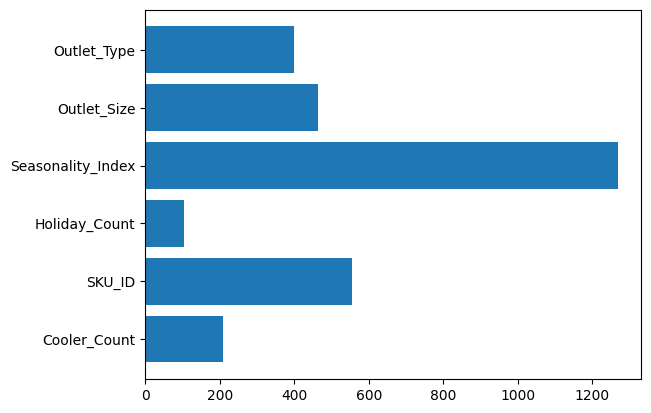

In [154]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.barh(features, importances)
plt.show()